# Keyword analysis

In [1]:
import polars as pl
import polars_corpus as plc
from scipy.stats import spearmanr
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pl.Config.set_tbl_rows(20)
pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

pio.templates["my_template"] = pio.templates["plotly_white"]
pio.templates["my_template"].layout.height = 600
pio.templates["my_template"].layout.width = 600
pio.templates.default = "my_template"
pio.renderers.default = "svg"

In [2]:
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(3)

polars.config.Config

In [3]:
bnc = pl.scan_parquet("../../data/bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("../../data/bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

Stefanowitsch (2020), pp. 378–380

In [15]:
mens_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).head(100).select('token','target_df','LogLik').collect(engine="streaming")
mens_keywords.head(10)

token,target_df,LogLik
str,u32,f64
"""fucking""",47,"1,237.921"
"""er""",130,900.794
"""the""",134,574.377
""",""",133,380.467
"""yeah""",131,305.647
"""minus""",10,299.750
"""<unclear/>""",132,269.419
"""aye""",66,258.852
"""hundred""",96,249.382


In [34]:
womens_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).select('token','target_df','LogLik').collect(engine="streaming")
womens_keywords.head(10)

token,target_df,LogLik
str,u32,f64
"""she""",130,"3,373.992"
"""her""",129,"1,017.036"
"""said""",131,915.451
"""n't""",135,494.184
"""i""",137,369.237
"""and""",136,271.296
"""to""",135,207.086
"""cos""",129,204.473
"""christmas""",86,175.169


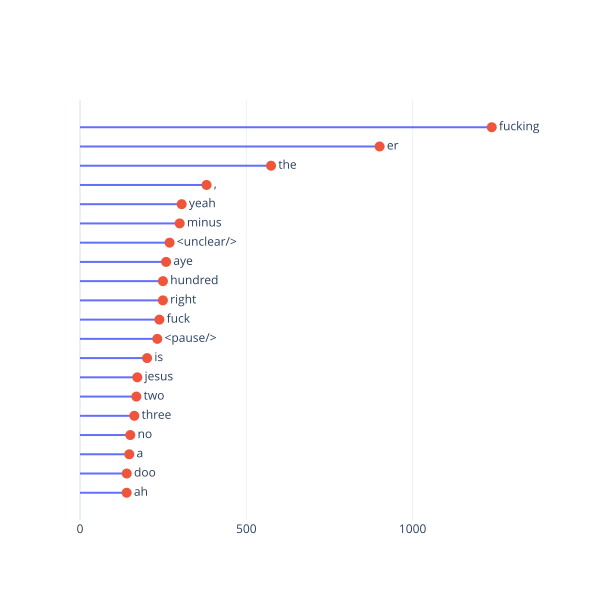

In [31]:
plc.keyword_plot(mens_keywords, 'token', 'LogLik', top_k=20, descending=True)

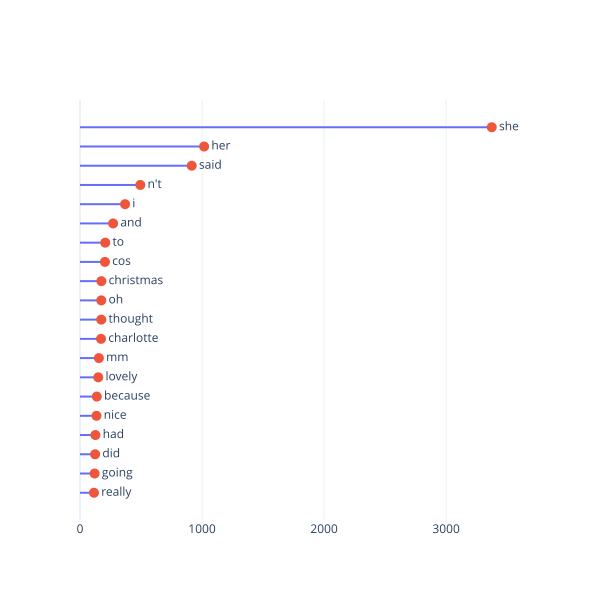

In [7]:
plc.keyword_plot(womens_keywords, 'token', 'LogLik', top_k=20, descending=True)

Lijffijt et al. (2016)

In [4]:
tt_mens_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).head(100).collect()
tt_mens_keywords

token,t,p,df,e
str,f64,f64,f64,f64
"""er""",3.979,0.000,207.298,0.480
"""which""",3.687,0.000,192.910,0.445
"""c""",3.657,0.000,201.534,0.442
"""quid""",3.537,0.000,231.138,0.427
"""ah""",3.418,0.001,206.286,0.413
"""hundred""",3.346,0.001,240.972,0.404
"""against""",3.331,0.001,197.162,0.402
"""chap""",3.153,0.002,159.891,0.380
"""mate""",3.151,0.002,163.768,0.380


In [5]:
tt_womens_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).head(100).collect()
tt_womens_keywords.sort(by='e', descending=True)

token,t,p,df,e
str,f64,f64,f64,f64
"""she""",7.102,0.000,214.777,0.856
"""her""",4.983,0.000,270.939,0.602
"""to""",4.964,0.000,270.949,0.599
"""lovely""",4.706,0.000,203.745,0.567
"""children""",3.961,0.000,241.274,0.478
"""did""",3.932,0.000,262.944,0.474
"""shopping""",3.923,0.000,183.692,0.472
"""likes""",3.842,0.000,195.918,0.463
"""really""",3.837,0.000,228.945,0.463


In [6]:
both = tt_womens_keywords.join(tt_womens_keywords, how='inner', on='token')

In [7]:
both.head(20)

token,t,p,df,e,t_right,p_right,df_right,e_right
str,f64,f64,f64,f64,f64,f64,f64,f64
"""she""",7.102,0.000,214.777,0.856,7.102,0.000,214.777,0.856
"""her""",4.983,0.000,270.939,0.602,4.983,0.000,270.939,0.602
"""to""",4.964,0.000,270.949,0.599,4.964,0.000,270.949,0.599
"""lovely""",4.706,0.000,203.745,0.567,4.706,0.000,203.745,0.567
"""children""",3.961,0.000,241.274,0.478,3.961,0.000,241.274,0.478
"""did""",3.932,0.000,262.944,0.474,3.932,0.000,262.944,0.474
"""shopping""",3.923,0.000,183.692,0.472,3.923,0.000,183.692,0.472
"""really""",3.837,0.000,228.945,0.463,3.837,0.000,228.945,0.463
"""likes""",3.842,0.000,195.918,0.463,3.842,0.000,195.918,0.463


In [9]:
spearmanr(both['LogLik'], both['t'])

ColumnNotFoundError: "LogLik" not found

In [40]:
spearmanr(both['t'], both['target_df'])

SignificanceResult(statistic=np.float64(0.37818747337171277), pvalue=np.float64(0.00010469670057609483))

In [41]:
spearmanr(both['LogLik'], both['target_df'])

SignificanceResult(statistic=np.float64(0.7357429046195616), pvalue=np.float64(2.8117523163744655e-18))

In [8]:
spearmanr(tt_womens_keywords['t'], tt_womens_keywords['e'])

SignificanceResult(statistic=np.float64(0.9993999399939993), pvalue=np.float64(6.040850578211737e-145))